In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import bayesflow as bf

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


In [4]:
from simulators.benchmarks import DDM

In [12]:
num_obs = 200
num_train = 10000
num_val = 200
epochs = 100
batch_size = 32

### Workflow

In [13]:
simulator = DDM()

In [14]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(["v", "a", "tau", "s_v", "s_tau", "decay"], axis=-1, into="inference_variables")
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [15]:
summary_network = bf.networks.SetTransformer(summary_dim=16, seed_dim=128)
inference_network = bf.networks.FlowMatching()

In [16]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_baseline_{num_obs}.ckpt",
)

In [17]:
train_set = workflow.simulate(num_train)
val_set = workflow.simulate(num_val)

In [18]:
for k, v in train_set.items():
    print(f"{k}: {v.shape}")

v: (10000, 1)
a: (10000, 1)
decay: (10000, 1)
tau: (10000, 1)
s_v: (10000, 1)
s_tau: (10000, 1)
rts: (10000, 200, 1)
choices: (10000, 200, 1)


In [19]:
history = workflow.fit_offline(
    data=train_set,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=val_set,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 4.0951 - val_loss: 1.5515
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 1.6789 - val_loss: 1.1806
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 1.3396 - val_loss: 1.0023
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 1.2065 - val_loss: 1.2176
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 1.1517 - val_loss: 1.0643
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 1.1088 - val_loss: 1.0666
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 1.0383 - val_loss: 1.0678
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.9641 - val_loss: 1.0161
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.9330 - val_loss: 0.7963
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.9010 - val_loss: 0.7906
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.8782 - val_loss: 0.9112
Epoch 12/100
313/313

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_baseline_200.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


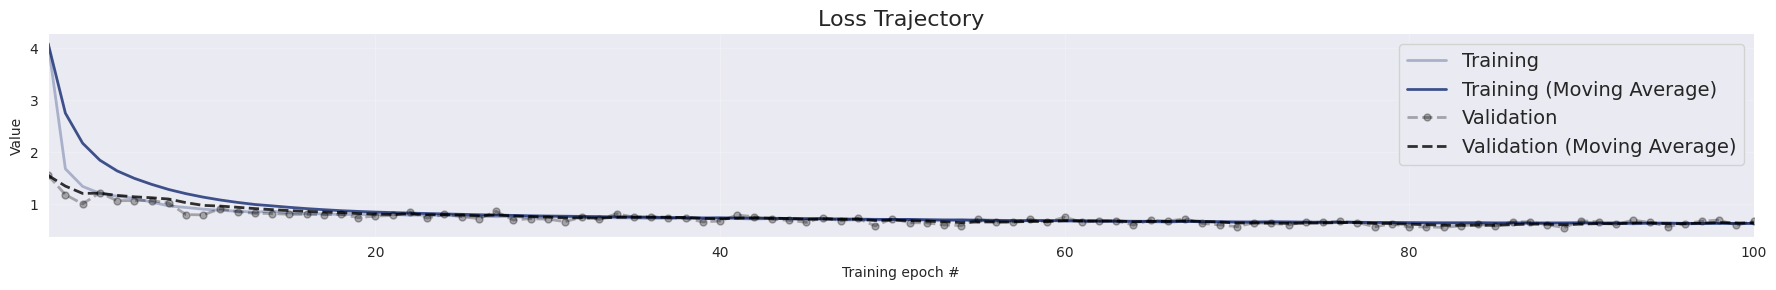

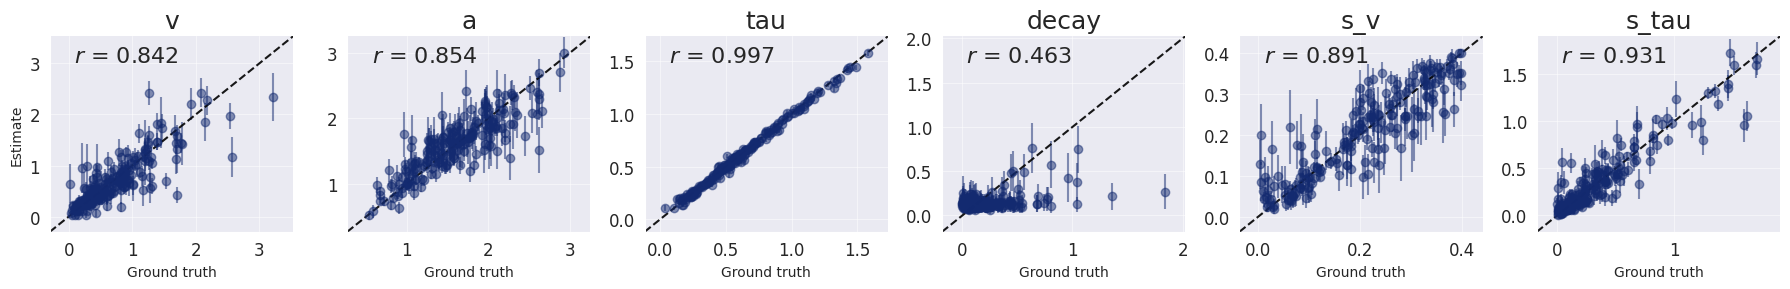

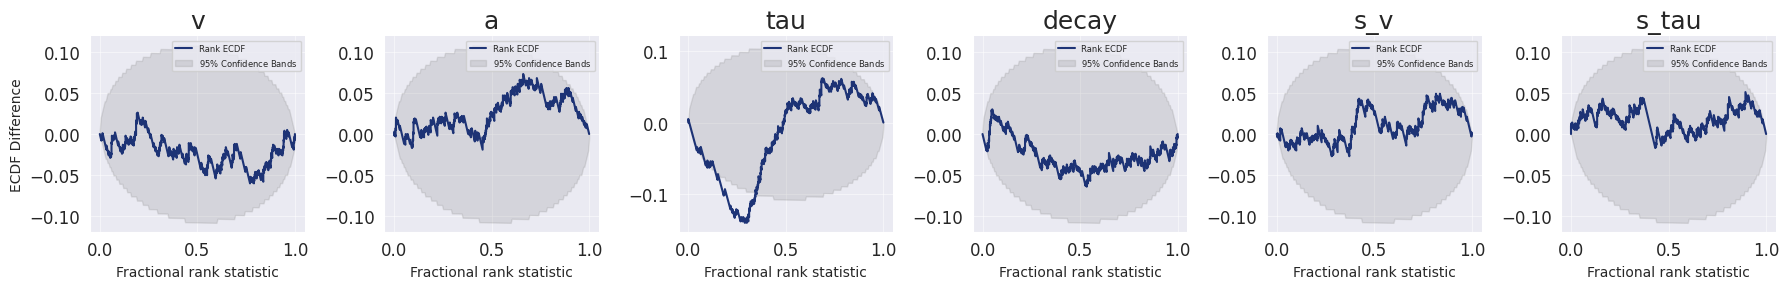

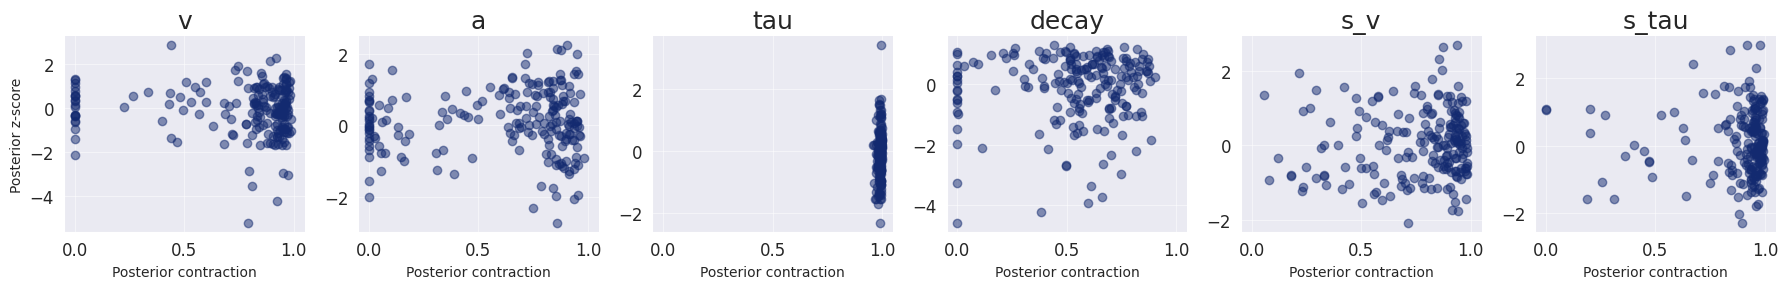

In [24]:
fig = workflow.plot_default_diagnostics(
    test_data=val_set,
    variable_names=["v", "a", "tau", "decay", "s_v", "s_tau"],
    num_samples=500,
    loss_kwargs={"figsize": (18, 3), "label_fontsize": 10},
    recovery_kwargs={"figsize": (18, 3), "label_fontsize": 10},
    calibration_ecdf_kwargs={"figsize": (18, 3), "legend_fontsize": 6, "difference": True, "label_fontsize": 10},
    z_score_contraction_kwargs={"figsize": (18, 3), "label_fontsize": 10}
)